# Function 6 Analysis - Week 11

1. **Function description (unchanged):**  
You're optimising a cake recipe using a black-box function with five ingredient inputs (e.g., flour, sugar, eggs, butter, milk). Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost. The score is negative by design (closer to zero = better). Goal: maximise the score (get it as close to zero as possible).

2. **Week 10 evaluated point:** `(0.453333, 0.150000, 0.616667, 0.800000, 0.096667)` returned **≈-0.3265**, so it is a **new maximum** (closer to zero).

3. **Why last week likely worked (re-read of Week 10 logic):** The improvement was not random; it came from a specific policy shift:
- **No incumbent fallback**: the optimizer was forced to commit to a genuine non-incumbent move instead of defaulting back to the current best.
- **Higher uncertainty weight (`beta=0.45`)**: this increased the value of informative candidates that exploit-only logic had been underweighting.
- **Lower disagreement penalty (`gamma=0.02`)**: GP/RF disagreement was still monitored, but no longer over-penalized potentially useful moves.
- **Still local**: the move remained in the same promising basin, so exploration was controlled rather than global.

4. **Interpretation:** This is consistent with a plateau-break mechanism: we were previously too conservative, and the reweighted ensemble UCB allowed a nearby but nontrivial step that found a better pocket.

5. **Recommendation for Week 12 (and why):** Keep the same ensemble framework and local basin focus, but continue with controlled non-incumbent moves (small step, information-aware) to test whether this is a sustained upward track rather than a one-off jump. 

## Loading and Displaying the Data

We load the inputs and outputs for function 6. Week 10 `(0.453333, 0.150000, 0.616667, 0.800000, 0.096667)` returned **≈-0.3265** and has been added to the dataset.


In [13]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_6")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.385900, 0.100000, 0.900000, 0.900000, 0.100000]])
y_new_point_week_1 = np.array([-0.6776496956465717])
X_new_point_week_2 = np.array([[0.497100, 0.099400, 0.867700, 0.927400, 0.080100]])
y_new_point_week_2 = np.array([-0.6699189536985941])
X_new_point_week_3 = np.array([[0.490200, 0.105300, 0.800500, 0.891800, 0.090600]])
y_new_point_week_3 = np.array([-0.6254082247545762])
X_new_point_week_4 = np.array([[0.515000, 0.115000, 0.835000, 0.900000, 0.095000]])
y_new_point_week_4 = np.array([-0.6176776319731351])
X_new_point_week_5 = np.array([[0.471200, 0.096000, 0.621500, 0.902500, 0.056100]])
y_new_point_week_5 = np.array([-0.4431798937405181])
X_new_point_week_6 = np.array([[0.333400, 0.146100, 0.857900, 0.870200, 0.851500]])
y_new_point_week_6 = np.array([-1.3624613199388411])
X_new_point_week_7 = np.array([[0.442187, 0.088811, 0.577781, 0.921921, 0.028055]])
y_new_point_week_7 = np.array([-0.65087])
X_new_point_week_8 = np.array([[0.477907, 0.146241, 0.495370, 0.945008, 0.013763]])
y_new_point_week_8 = np.array([-0.6441194582450214])
X_new_point_week_9 = np.array([[0.466667, 0.150000, 0.611111, 0.850000, 0.091111]])
y_new_point_week_9 = np.array([-0.435125895502132])
X_new_point_week_10 = np.array([[0.453333, 0.150000, 0.616667, 0.800000, 0.096667]])
y_new_point_week_10 = np.array([-0.3265340913684774])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


df sorted by y


,x1,x2,x3,x4,x5,y,x_avg
0,0.453333,0.150000,0.616667,0.800000,0.096667,-0.326534,0.423333
1,0.466667,0.150000,0.611111,0.850000,0.091111,-0.435126,0.433778
2,0.471200,0.096000,0.621500,0.902500,0.056100,-0.443180,0.429460
3,0.515000,0.115000,0.835000,0.900000,0.095000,-0.617678,0.492000
4,0.490200,0.105300,0.800500,0.891800,0.090600,-0.625408,0.475680
5,0.477907,0.146241,0.495370,0.945008,0.013763,-0.644119,0.415658
6,0.442187,0.088811,0.577781,0.921921,0.028055,-0.650870,0.411751
7,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,0.494340
8,0.385900,0.100000,0.900000,0.900000,0.100000,-0.677650,0.477180
9,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265,0.473166


## Weekly Optimization Progress Summary

Overview of all 10 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 10 update:** `(0.453333, 0.150000, 0.616667, 0.800000, 0.096667)` → **≈-0.3265** (**new maximum**).


In [14]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 120)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 120)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.6f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,y,Running_Max,Status,Improvement
0,1,0.385900,0.100000,0.900000,0.900000,0.100000,-0.677650,-0.677650,✓ NEW MAX,+1.000000
1,2,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,-0.669919,✓ NEW MAX,+0.007731
2,3,0.490200,0.105300,0.800500,0.891800,0.090600,-0.625408,-0.625408,✓ NEW MAX,+0.044511
3,4,0.515000,0.115000,0.835000,0.900000,0.095000,-0.617678,-0.617678,✓ NEW MAX,+0.007731
4,5,0.471200,0.096000,0.621500,0.902500,0.056100,-0.443180,-0.443180,✓ NEW MAX,+0.174498
5,6,0.333400,0.146100,0.857900,0.870200,0.851500,-1.362461,-0.443180,✗,-
6,7,0.442187,0.088811,0.577781,0.921921,0.028055,-0.650870,-0.443180,✗,-
7,8,0.477907,0.146241,0.495370,0.945008,0.013763,-0.644119,-0.443180,✗,-
8,9,0.466667,0.150000,0.611111,0.850000,0.091111,-0.435126,-0.435126,✓ NEW MAX,+0.008054
9,10,0.453333,0.150000,0.616667,0.800000,0.096667,-0.326534,-0.326534,✓ NEW MAX,+0.108592



📊 Summary: 7/10 weeks achieved new max (Weeks [1, 2, 3, 4, 5, 9, 10])
   Success rate: 70.0% | Final best: -0.326534


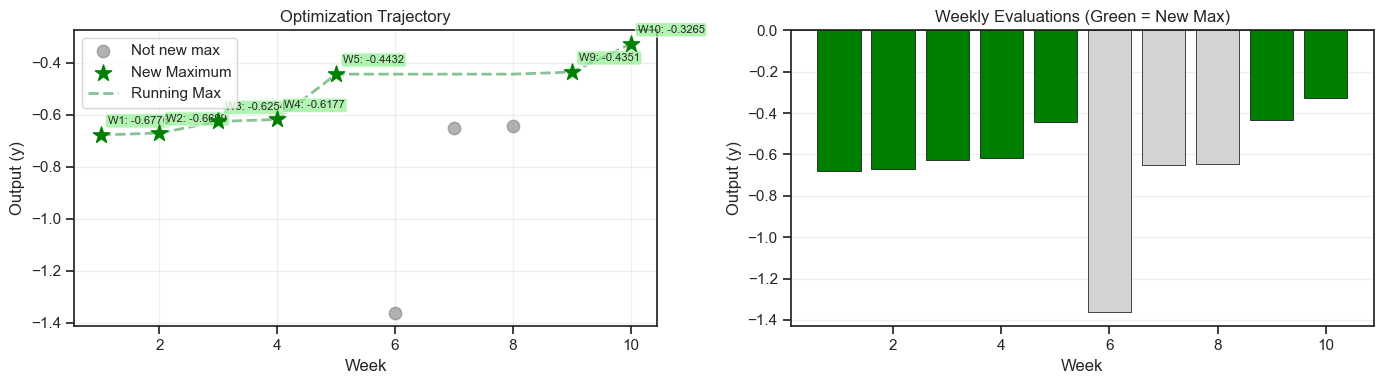

In [15]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Week 10 Result:**
- `(0.453333, 0.150000, 0.616667, 0.800000, 0.096667)` scored **≈-0.3265** — new maximum (closer to zero is better).
- This likely worked because the Week 10 policy removed incumbent fallback and reweighted UCB toward uncertainty (`beta=0.45`) while reducing over-penalization from model disagreement (`gamma=0.02`).
- In practice, this allowed a meaningful non-incumbent local move that stayed in-basin but escaped the previous conservative plateau behavior.

**Current best is now:** `(0.453333, 0.150000, 0.616667, 0.800000, 0.096667)` at ≈-0.3265 (Week 10)


In [16]:
from scipy.stats import norm

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function.
    
    Args:
        x: Point to evaluate
        gp: Fitted Gaussian Process
        y_best: Best observed value so far
        xi: Exploration-exploitation trade-off parameter (small values favor exploitation)
    
    Returns:
        Negative EI (for minimization)
    """
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    
    # Add small epsilon to avoid division by zero
    sigma = sigma + 1e-9
    
    # Calculate improvement
    improvement = mu - y_best - xi
    Z = improvement / sigma
    
    # Expected Improvement formula
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei[0]  # Return negative for minimization


# Boundary penalty function
def boundary_penalty(x, margin=0.15, penalty_strength=2.0):
    """
    Add a penalty for points near the boundaries to avoid extreme values.
    
    Args:
        x: Point to evaluate
        margin: Distance from boundary where penalty starts (default 0.15)
        penalty_strength: Strength of the penalty (default 2.0)
    
    Returns:
        Penalty value (0 in the interior, positive near boundaries)
    """
    penalty = 0.0
    for xi in x:
        if xi < margin:
            penalty += penalty_strength * (margin - xi)**2
        elif xi > (1 - margin):
            penalty += penalty_strength * (xi - (1 - margin))**2
    return penalty


# Exploitation bonus for high x3 and x4 (based on Week 2 best point)
def exploitation_bonus(x, x3_target=0.87, x4_target=0.90, bonus_strength=1.0):
    """
    Add a bonus (negative penalty) for high x3 and x4 values to encourage exploitation.
    This version leans harder on x3 to avoid large downward moves.
    """
    bonus = 0.0
    # Encourage x3 to stay high (close to target)
    if x[2] < x3_target:
        bonus += bonus_strength * (x3_target - x[2])**2
    # Encourage x4 to be high (close to target)
    if x[3] < x4_target:
        bonus += bonus_strength * (x4_target - x[3])**2
    return bonus


# Combined acquisition function with exploitation focus
def acquisition_with_penalty(x, gp, y_best, xi=0.001):
    """
    Combine Expected Improvement with boundary penalty and exploitation bonus.
    Lower xi (0.001) favors exploitation over exploration.
    """
    ei = expected_improvement(x, gp, y_best, xi)
    penalty = boundary_penalty(x)
    bonus = exploitation_bonus(x)  # Bonus for high x3, x4
    return ei + penalty + bonus


# Display current best
y_best = y.max()
best_idx = y.argmax()
print(f"Current best score: {y_best:.4f}")
print(f"Current best recipe: {X[best_idx]}")
print(f"  x1={X[best_idx, 0]:.4f}, x2={X[best_idx, 1]:.4f}, x3={X[best_idx, 2]:.4f}, x4={X[best_idx, 3]:.4f}, x5={X[best_idx, 4]:.4f}")


Current best score: -0.3265
Current best recipe: [0.453333 0.15     0.616667 0.8      0.096667]
  x1=0.4533, x2=0.1500, x3=0.6167, x4=0.8000, x5=0.0967


## Ensemble Surrogate: GP + Random Forest

GP-only guidance was unstable in this function, so we use an ensemble (GP + RF) for robustness. RF-only is possible, but in this setting the ensemble is safer: it keeps GP uncertainty structure while using RF to reduce smooth-model bias. We average predictions and use model disagreement as an additional uncertainty signal for candidate ranking.

In [17]:
# Ensemble Surrogate: GP + Random Forest
# ========================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor

# Current best
best_idx = df['y'].idxmax()
best_point = df.loc[best_idx]
best_y = best_point['y']
print(f"Current best: ({best_point['x1']:.4f}, {best_point['x2']:.4f}, {best_point['x3']:.4f}, {best_point['x4']:.4f}, {best_point['x5']:.4f}) = {best_y:.4f}")
print(f"Week 8 result: -0.6441 (worse than best)\n")

# === Model 1: Gaussian Process ===
gp_kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.2]*5, length_scale_bounds=(0.01, 1.0), nu=2.5)
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-3, 0.5))
)
gp = GaussianProcessRegressor(kernel=gp_kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}")

# === Model 2: Random Forest ===
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y.ravel())
print(f"Random Forest fitted. Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}, x3={rf.feature_importances_[2]:.3f}, x4={rf.feature_importances_[3]:.3f}, x5={rf.feature_importances_[4]:.3f}\n")

# Search region: loosened local box (final step) to avoid one-variable-only updates
sr_x1 = (0.38, 0.60)
sr_x2 = (0.05, 0.20)
sr_x3 = (0.45, 0.75)
sr_x4 = (0.80, 0.98)
sr_x5 = (0.01, 0.14)

print("Search region (focused on Week 5 basin):")
print(f"  x1: [{sr_x1[0]}, {sr_x1[1]}]")
print(f"  x2: [{sr_x2[0]}, {sr_x2[1]}]")
print(f"  x3: [{sr_x3[0]}, {sr_x3[1]}]")
print(f"  x4: [{sr_x4[0]}, {sr_x4[1]}]")
print(f"  x5: [{sr_x5[0]}, {sr_x5[1]}]\n")

# Generate candidate grid
grid_res = 10  # 10^5 = 100,000 candidates
grid_x1 = np.linspace(sr_x1[0], sr_x1[1], grid_res)
grid_x2 = np.linspace(sr_x2[0], sr_x2[1], grid_res)
grid_x3 = np.linspace(sr_x3[0], sr_x3[1], grid_res)
grid_x4 = np.linspace(sr_x4[0], sr_x4[1], grid_res)
grid_x5 = np.linspace(sr_x5[0], sr_x5[1], grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4, grid_x5)).reshape(5, -1).T

print(f"Evaluating {len(mesh)} candidates with ensemble...")

# Get GP predictions
gp_mu, gp_sigma = gp.predict(mesh, return_std=True)

# Get RF predictions (mean and uncertainty from tree disagreement)
rf_tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_mu = rf_tree_preds.mean(axis=0)
rf_sigma = rf_tree_preds.std(axis=0)

# === Ensemble: average predictions, combine uncertainties ===
ensemble_mu = 0.5 * gp_mu + 0.5 * rf_mu  # Equal weight
ensemble_sigma = np.sqrt(0.5 * gp_sigma**2 + 0.5 * rf_sigma**2)  # Combined uncertainty

# Model disagreement as additional uncertainty signal
model_disagreement = np.abs(gp_mu - rf_mu)

# UCB acquisition: increase uncertainty term, loosen disagreement term
beta = 0.45   # Higher weight on predictive uncertainty
gamma = 0.02  # Lower weight on GP-RF disagreement
ensemble_ucb = ensemble_mu + beta * ensemble_sigma + gamma * model_disagreement

# Build candidate dataframe
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
candidates['gp_mu'] = gp_mu
candidates['gp_sigma'] = gp_sigma
candidates['rf_mu'] = rf_mu
candidates['rf_sigma'] = rf_sigma
candidates['ensemble_mu'] = ensemble_mu
candidates['ensemble_sigma'] = ensemble_sigma
candidates['disagreement'] = model_disagreement
candidates['ucb'] = ensemble_ucb

# Filter 1: minimum distance from existing observations
min_dist = 0.02
for _, obs in df.iterrows():
    dist = np.sqrt((candidates['x1'] - obs['x1'])**2 + 
                   (candidates['x2'] - obs['x2'])**2 +
                   (candidates['x3'] - obs['x3'])**2 +
                   (candidates['x4'] - obs['x4'])**2 +
                   (candidates['x5'] - obs['x5'])**2)
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter: {len(candidates)}")

# No incumbent fallback: rank all distance-feasible candidates directly by UCB
print("No incumbent fallback enabled; selecting best non-filtered UCB candidate.")

# Top candidates by ensemble UCB
top_candidates = candidates.nlargest(10, 'ucb')
print("\nTop 10 Ensemble candidates (by UCB):")
display(top_candidates[['x1', 'x2', 'x3', 'x4', 'x5', 'gp_mu', 'rf_mu', 'ensemble_mu', 'disagreement', 'ucb']])

# Recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    print(f"\n" + "="*60)
    print("ENSEMBLE RECOMMENDATION")
    print("="*60)
    print(f"Recommended: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f}, {rec['x5']:.6f})")
    print(f"GP prediction: {rec['gp_mu']:.4f}")
    print(f"RF prediction: {rec['rf_mu']:.4f}")
    print(f"Ensemble mean: {rec['ensemble_mu']:.4f}")
    print(f"Model disagreement: {rec['disagreement']:.4f}")
    print(f"\nSubmission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}-{rec['x5']:.6f}")


Current best: (0.4533, 0.1500, 0.6167, 0.8000, 0.0967) = -0.3265
Week 8 result: -0.6441 (worse than best)



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GP fitted. Kernel: 1.15**2 * Matern(length_scale=[0.618, 1, 1, 0.765, 0.827], nu=2.5) + WhiteKernel(noise_level=0.0109)
Random Forest fitted. Feature importances: x1=0.046, x2=0.208, x3=0.029, x4=0.341, x5=0.377

Search region (focused on Week 5 basin):
  x1: [0.38, 0.6]
  x2: [0.05, 0.2]
  x3: [0.45, 0.75]
  x4: [0.8, 0.98]
  x5: [0.01, 0.14]

Evaluating 100000 candidates with ensemble...
Candidates after distance filter: 99970
No incumbent fallback enabled; selecting best non-filtered UCB candidate.

Top 10 Ensemble candidates (by UCB):


,x1,x2,x3,x4,x5,gp_mu,rf_mu,ensemble_mu,disagreement,ucb
83506,0.453333,0.183333,0.616667,0.8,0.096667,-0.362286,-0.496707,-0.429497,0.134421,-0.370834
63406,0.453333,0.150000,0.583333,0.8,0.096667,-0.368981,-0.485546,-0.427263,0.116566,-0.371515
83406,0.453333,0.183333,0.583333,0.8,0.096667,-0.359339,-0.506273,-0.432806,0.146934,-0.372489
63306,0.453333,0.150000,0.550000,0.8,0.096667,-0.371411,-0.488622,-0.430017,0.117211,-0.373114
83306,0.453333,0.183333,0.550000,0.8,0.096667,-0.360894,-0.509349,-0.435122,0.148455,-0.373907
63606,0.453333,0.150000,0.650000,0.8,0.096667,-0.377693,-0.478382,-0.428037,0.100689,-0.374743
62506,0.428889,0.150000,0.616667,0.8,0.096667,-0.374847,-0.491800,-0.433324,0.116953,-0.374910
73406,0.453333,0.166667,0.583333,0.8,0.096667,-0.363685,-0.506273,-0.434979,0.142588,-0.374972
63206,0.453333,0.150000,0.516667,0.8,0.096667,-0.378216,-0.492607,-0.435411,0.114391,-0.375171
83206,0.453333,0.183333,0.516667,0.8,0.096667,-0.366824,-0.513333,-0.440079,0.146509,-0.375937



ENSEMBLE RECOMMENDATION
Recommended: (0.453333, 0.183333, 0.616667, 0.800000, 0.096667)
GP prediction: -0.3623
RF prediction: -0.4967
Ensemble mean: -0.4295
Model disagreement: 0.1344

Submission format: 0.453333-0.183333-0.616667-0.800000-0.096667


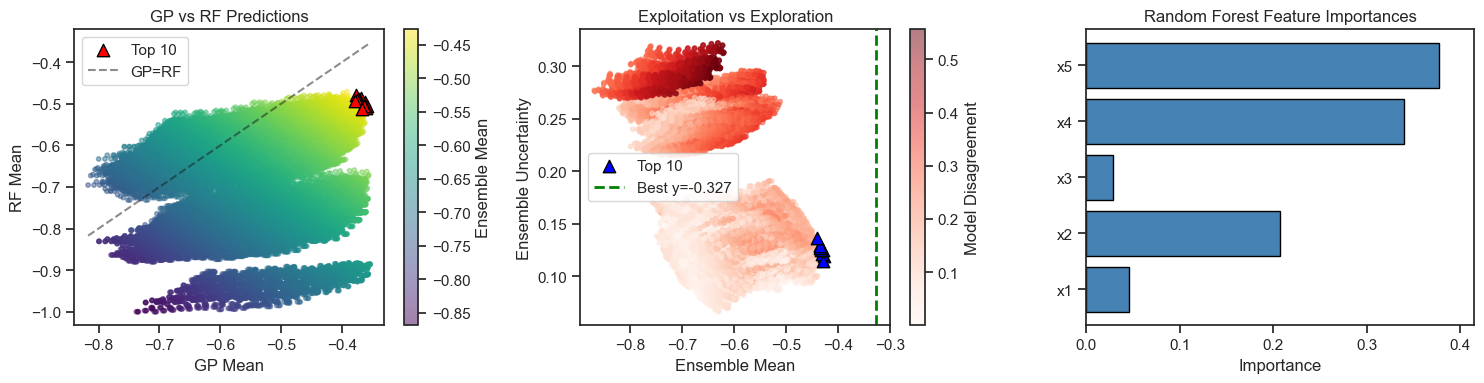

In [18]:
# Visualization: GP vs RF predictions + ensemble
# ================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]

# Plot 1: GP mean vs RF mean for all candidates
ax1 = axes[0]
scatter1 = ax1.scatter(candidates['gp_mu'], candidates['rf_mu'], c=candidates['ensemble_mu'], 
                       cmap='viridis', s=10, alpha=0.5)
ax1.scatter(top_candidates['gp_mu'], top_candidates['rf_mu'], c='red', s=80, 
            edgecolor='black', marker='^', label='Top 10')
ax1.plot([candidates['gp_mu'].min(), candidates['gp_mu'].max()], 
         [candidates['gp_mu'].min(), candidates['gp_mu'].max()], 'k--', alpha=0.5, label='GP=RF')
ax1.set_xlabel('GP Mean')
ax1.set_ylabel('RF Mean')
ax1.set_title('GP vs RF Predictions')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Ensemble Mean')

# Plot 2: Ensemble mean vs uncertainty
ax2 = axes[1]
scatter2 = ax2.scatter(candidates['ensemble_mu'], candidates['ensemble_sigma'], 
                       c=candidates['disagreement'], cmap='Reds', s=10, alpha=0.5)
ax2.scatter(top_candidates['ensemble_mu'], top_candidates['ensemble_sigma'], c='blue', s=80,
            edgecolor='black', marker='^', label='Top 10')
ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best y={best_y:.3f}')
ax2.set_xlabel('Ensemble Mean')
ax2.set_ylabel('Ensemble Uncertainty')
ax2.set_title('Exploitation vs Exploration')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Model Disagreement')

# Plot 3: Feature importance from RF
ax3 = axes[2]
features = ['x1', 'x2', 'x3', 'x4', 'x5']
importances = rf.feature_importances_
ax3.barh(features, importances, color='steelblue', edgecolor='black')
ax3.set_xlabel('Importance')
ax3.set_title('Random Forest Feature Importances')
ax3.set_xlim(0, max(importances) * 1.1)

plt.tight_layout()
plt.show()


**Current best:** `0.453333-0.150000-0.616667-0.800000-0.096667` (≈-0.3265) — new maximum.

**Week 10 evaluated point:** `0.453333-0.150000-0.616667-0.800000-0.096667` supports a genuine plateau break driven by the no-fallback + reweighted-UCB policy.

**Proposed next point (submission format):** `0.453333-0.183333-0.616667-0.800000-0.096667`

### Chart interpretation (simple)
- **GP vs RF plot:** top candidates sit where both models are relatively favorable, so the choice is not coming from one model alone.
- **Exploitation vs exploration plot:** selected points are near the best-score frontier but still carry uncertainty, i.e., controlled non-incumbent exploration.
- **RF importance plot:** `x5` and `x4` are strongest, then `x2`; `x1`/`x3` are weaker in this local region.

### BO constraints used in this step
- **Local search box:**
  - `x1 in [0.38, 0.60]`
  - `x2 in [0.05, 0.20]`
  - `x3 in [0.45, 0.75]`
  - `x4 in [0.80, 0.98]`
  - `x5 in [0.01, 0.14]`
- **Distance filter:** keep candidates at least `0.02` away from existing points.
- **Acquisition rule:** ensemble UCB with `beta=0.45`, `gamma=0.02`.
- **No incumbent fallback:** we force a non-incumbent recommendation.
